In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Directories
csv_dir = Path("/home/paul/Msci/ntuples/cos_theta_csvs/")
plot_dir = Path("/home/paul/Msci/plots/sensitivity/")

# NuMI beam direction (for reference)
v_numi = np.array([0.462372, 0.0488541, 0.885339])

# POT and scaling factors (Run 1 only)
target_pot_run1 = 2.2e20

scalings_run1 = {
    "nu": 1.0 / 2.35e21,
    "dirt": 1.026 * 0.75 / 1.6e21,
    "beamoff": 0.98 * (6230439.0 / 9186361.390000)
}

In [2]:
# Load signal files
signal_files = sorted(csv_dir.glob("run1_dt_ratio_0.6*_cos_theta.csv"))
signal_dfs = {}
for f in signal_files:
    # Extract mass and decay mode from filename
    name = f.stem.replace("_cos_theta", "")
    signal_dfs[name] = pd.read_csv(f)
    print(f"Loaded {name}: {len(signal_dfs[name])} events")

print(f"\nTotal signal files: {len(signal_dfs)}")

Loaded run1_dt_ratio_0.6_ma_0.01_pi0_sp: 7180 events
Loaded run1_dt_ratio_0.6_ma_0.02_eta_sp: 7335 events
Loaded run1_dt_ratio_0.6_ma_0.02_pi0_sp: 10252 events
Loaded run1_dt_ratio_0.6_ma_0.03_eta_sp: 6155 events
Loaded run1_dt_ratio_0.6_ma_0.03_pi0_sp: 7642 events
Loaded run1_dt_ratio_0.6_ma_0.04_eta_sp: 9885 events
Loaded run1_dt_ratio_0.6_ma_0.04_pi0_sp: 9764 events
Loaded run1_dt_ratio_0.6_ma_0.05_eta_sp: 9784 events
Loaded run1_dt_ratio_0.6_ma_0.05_pi0_sp: 7910 events
Loaded run1_dt_ratio_0.6_ma_0.06_eta_sp: 9294 events
Loaded run1_dt_ratio_0.6_ma_0.06_pi0_sp: 8504 events
Loaded run1_dt_ratio_0.6_ma_0.07_eta_sp: 6902 events
Loaded run1_dt_ratio_0.6_ma_0.07_pi0_sp: 7561 events
Loaded run1_dt_ratio_0.6_ma_0.08_eta_sp: 7633 events
Loaded run1_dt_ratio_0.6_ma_0.08_pi0_sp: 7735 events
Loaded run1_dt_ratio_0.6_ma_0.09_eta_sp: 7852 events
Loaded run1_dt_ratio_0.6_ma_0.09_pi0_sp: 6487 events
Loaded run1_dt_ratio_0.6_ma_0.1_eta_sp: 16759 events
Loaded run1_dt_ratio_0.6_ma_0.2_eta_sp: 12555

In [3]:
# Load backgrounds
df_nu = pd.read_csv(csv_dir / "run1_nu_overlay_cos_theta.csv")
df_dirt = pd.read_csv(csv_dir / "run1_dirt_cos_theta.csv")
df_offbeam = pd.read_csv(csv_dir / "run1_offbeam_cos_theta.csv")

print(f"Nu overlay: {len(df_nu)} events")
print(f"Dirt: {len(df_dirt)} events")
print(f"Offbeam: {len(df_offbeam)} events")

# Load NC backgrounds (for comparison)
df_ncpi0 = pd.read_csv(csv_dir / "NCPi0_cos_theta.csv")
df_nceta = pd.read_csv(csv_dir / "NCeta_cos_theta.csv")

print(f"NCPi0: {len(df_ncpi0)} events")
print(f"NCeta: {len(df_nceta)} events")

Nu overlay: 131891 events
Dirt: 24016 events
Offbeam: 38792 events
NCPi0: 26077 events
NCeta: 28767 events


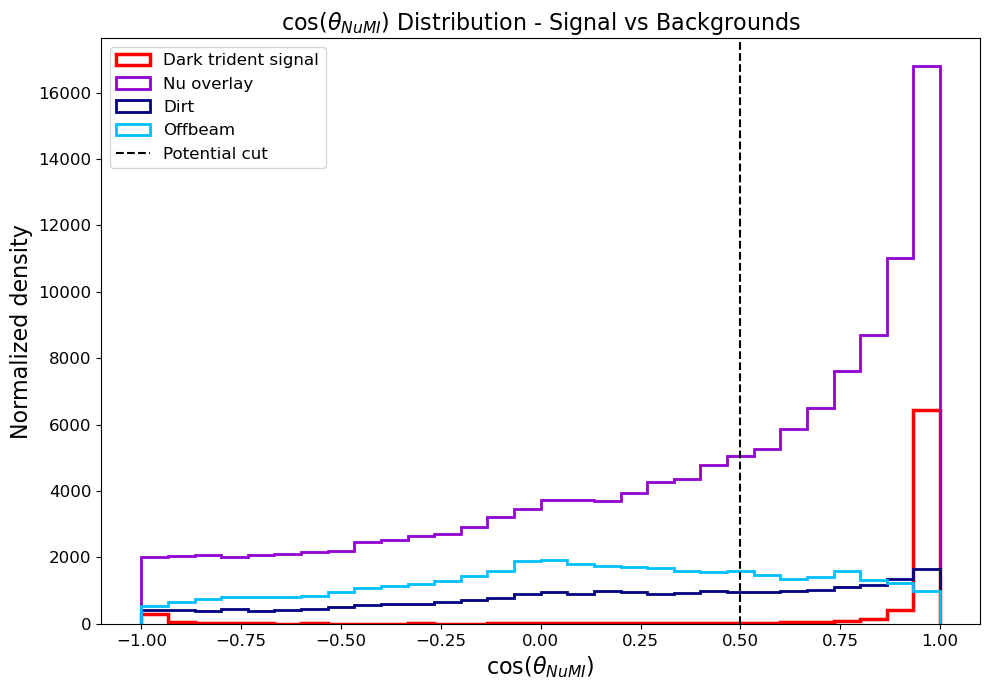


Fraction with cos(θ) > 0.5:
  Signal: 91.9%
  Nu overlay: 48.7%
  Dirt: 36.1%
  Offbeam: 26.1%


In [4]:
fig, ax = plt.subplots(figsize=(10, 7))

bins = np.linspace(-1, 1, 31)

# Pick one signal mass point for now
df_sig = signal_dfs["run1_dt_ratio_0.6_ma_0.05_pi0_sp"]

ax.hist(df_sig['cos_theta'], bins=bins, density=False, histtype='step', 
        linewidth=2.5, color='red', label='Dark trident signal')
ax.hist(df_nu['cos_theta'], bins=bins, density=False, histtype='step', 
        linewidth=2, color='darkviolet', label='Nu overlay')
ax.hist(df_dirt['cos_theta'], bins=bins, density=False, histtype='step', 
        linewidth=2, color='navy', label='Dirt')
ax.hist(df_offbeam['cos_theta'], bins=bins, density=False, histtype='step', 
        linewidth=2, color='deepskyblue', label='Offbeam')

ax.axvline(0.5, color='black', linestyle='--', linewidth=1.5, label='Potential cut')

ax.set_xlabel(r'cos($\theta_{NuMI}$)', fontsize=16)
ax.set_ylabel('Normalized density', fontsize=16)
ax.set_title(r'cos($\theta_{NuMI}$) Distribution - Signal vs Backgrounds', fontsize=16)
ax.legend(fontsize=12)
ax.tick_params(labelsize=12)

plt.tight_layout()
plt.savefig(plot_dir / "cos_theta_signal_vs_background.png", dpi=150)
plt.show()

# Quick stats
print(f"\nFraction with cos(θ) > 0.5:")
print(f"  Signal: {(df_sig['cos_theta'] > 0.5).mean():.1%}")
print(f"  Nu overlay: {(df_nu['cos_theta'] > 0.5).mean():.1%}")
print(f"  Dirt: {(df_dirt['cos_theta'] > 0.5).mean():.1%}")
print(f"  Offbeam: {(df_offbeam['cos_theta'] > 0.5).mean():.1%}")

In [5]:
# Import pyhf
import pyhf

# Match CNN parameters exactly
nominal_eps = 1e-3
scaling_factor = 0.05
fraction_outside = 1.1

# Define cos(θ) bins - use FEWER bins for stability!
cosbins = np.array([0.0, 0.5, 1.0])  # Just 3 bins

print(f"cos(θ) bins: {cosbins}")
print(f"Number of bins: {len(cosbins) - 1}")

# Check what columns you have
print("df_nu columns:", df_nu.columns.tolist())
print("df_dirt columns:", df_dirt.columns.tolist())
print("df_offbeam columns:", df_offbeam.columns.tolist())


cos(θ) bins: [0.  0.5 1. ]
Number of bins: 2
df_nu columns: ['run', 'subrun', 'event', 'cos_theta', 'weight_spline', 'weight_tune', 'weight']
df_dirt columns: ['run', 'subrun', 'event', 'cos_theta', 'weight_spline', 'weight_tune', 'weight']
df_offbeam columns: ['run', 'subrun', 'event', 'cos_theta', 'weight_spline', 'weight_tune', 'weight']


In [6]:
# Background scalings (already defined earlier in your notebook)
nu_scaling = target_pot_run1 * scalings_run1['nu']
dirt_scaling = target_pot_run1 * scalings_run1['dirt']
offbeam_scaling = scalings_run1['beamoff']

# Filter to signal region: cos(θ) > 0
df_nu_sr = df_nu[df_nu['cos_theta'] > 0].copy()
df_dirt_sr = df_dirt[df_dirt['cos_theta'] > 0].copy()
df_offbeam_sr = df_offbeam[df_offbeam['cos_theta'] > 0].copy()

# Histogram backgrounds
hist_nu, _ = np.histogram(df_nu_sr['cos_theta'], bins=cosbins, weights=df_nu_sr['weight'])
hist_dirt, _ = np.histogram(df_dirt_sr['cos_theta'], bins=cosbins, weights=df_dirt_sr['weight'])
hist_offbeam, _ = np.histogram(df_offbeam_sr['cos_theta'], bins=cosbins)

# Apply POT scaling
hist_nu = hist_nu * nu_scaling
hist_dirt = hist_dirt * dirt_scaling
hist_offbeam = hist_offbeam * offbeam_scaling

# Total background
hist_bkg = hist_nu + hist_dirt + hist_offbeam
nbkg = hist_bkg.tolist()

print(f"Background in cos(θ) bins:")
print(f"  Nu:      {hist_nu}")
print(f"  Dirt:    {hist_dirt}")
print(f"  Offbeam: {hist_offbeam}")
print(f"  Total:   {hist_bkg} (sum={hist_bkg.sum():.1f} events)")


Background in cos(θ) bins:
  Nu:      [2901.65957447 6018.54468085]
  Dirt:    [755.13920625 917.3401875 ]
  Offbeam: [8542.90752191 6720.40285957]
  Total:   [12199.70630263 13656.28772792] (sum=25856.0 events)


In [7]:
# Correction factors (from CNN analysis)
correction_dica = {
    'pi0': {0.01: 11.198, 0.02: 11.145, 0.03: 10.861, 0.04: 11.543, 0.05: 10.671,
            0.06: 10.098, 0.07: 8.741, 0.08: 10.282, 0.09: 9.333},
    'eta': {0.02: 10.555, 0.03: 9.759, 0.04: 7.934, 0.05: 9.387, 0.06: 9.863,
            0.07: 10.301, 0.08: 9.141, 0.09: 7.273, 0.1: 7.228, 0.2: 7.597,
            0.3: 5.219, 0.4: 4.498}
}

# Meson scalings
meson_scalings = {'pi0': 11.7, 'eta': 7.2}

# Total POT (from CNN analysis) - UPDATED keys with underscores
total_pot = {
    'run1_dt_ratio_0.6_ma_0.01_pi0': 3.583299e20,
    'run1_dt_ratio_0.6_ma_0.02_eta': 1.971339e22,
    'run1_dt_ratio_0.6_ma_0.02_pi0': 3.785739e21,
    'run1_dt_ratio_0.6_ma_0.03_eta': 6.018737e22,
    'run1_dt_ratio_0.6_ma_0.03_pi0': 1.403744e22,
    'run1_dt_ratio_0.6_ma_0.04_eta': 2.797252e23,
    'run1_dt_ratio_0.6_ma_0.04_pi0': 6.144923e22,
    'run1_dt_ratio_0.6_ma_0.05_eta': 6.491310e23,
    'run1_dt_ratio_0.6_ma_0.05_pi0': 1.594137e23,
    'run1_dt_ratio_0.6_ma_0.06_eta': 1.333156e24,
    'run1_dt_ratio_0.6_ma_0.06_pi0': 5.428614e23,
    'run1_dt_ratio_0.6_ma_0.07_eta': 1.726805e24,
    'run1_dt_ratio_0.6_ma_0.07_pi0': 2.122624e24,
    'run1_dt_ratio_0.6_ma_0.08_eta': 3.721201e24,
    'run1_dt_ratio_0.6_ma_0.08_pi0': 9.137349e24,
    'run1_dt_ratio_0.6_ma_0.09_eta': 6.937703e24,
    'run1_dt_ratio_0.6_ma_0.09_pi0': 4.752829e25,
    'run1_dt_ratio_0.6_ma_0.1_eta': 2.632356e25,
    'run1_dt_ratio_0.6_ma_0.2_eta': 2.642929e27,
    'run1_dt_ratio_0.6_ma_0.3_eta': 4.548050e29,
    'run1_dt_ratio_0.6_ma_0.4_eta': 2.856632e32,
}

# Cross-section uncertainties (from CNN)
xsec_uncert_a = {
    'pi0': {0.01: 1.16, 0.02: 2.27, 0.03: 3.48, 0.04: 4.48, 0.05: 5.50,
            0.06: 5.92, 0.07: 7.17, 0.08: 8.55, 0.09: 8.97},
    'eta': {0.02: 2.09, 0.03: 3.50, 0.04: 4.33, 0.05: 6.07, 0.06: 6.26,
            0.07: 7.45, 0.08: 8.72, 0.09: 8.99, 0.1: 9.63, 0.2: 18.95,
            0.3: 22.04, 0.4: 30.34}
}

def get_signal_scaling(mass, dmode):
    """Calculate signal scaling matching CNN method"""
    # FIX: Use underscore format to match total_pot keys
    key = f'run1_dt_ratio_0.6_ma_{mass}_{dmode}'
    pot = total_pot[key]
    scale = meson_scalings[dmode] * target_pot_run1 * correction_dica[dmode][mass] / pot
    return scale

def load_signal_for_mass(mass):
    """Load and histogram signal for given mass"""
    hist_signal = np.zeros(len(cosbins) - 1)
    
    # Determine decay modes
    if mass <= 0.01:
        decay_modes = ['pi0']
    elif float(mass) >= 0.1:
        decay_modes = ['eta']
    else:
        decay_modes = ['pi0', 'eta']
    
    for dmode in decay_modes:
        # FIX: Use underscore format with _sp suffix
        key = f'run1_dt_ratio_0.6_ma_{mass}_{dmode}_sp'
        if key not in signal_dfs:
            print(f"  Warning: {key} not found")
            continue
        
        df = signal_dfs[key]
        
        # Filter to signal region (cos_theta > 0)
        df_sr = df[df['cos_theta'] > 0].copy()
        
        # Get scaling
        scale = get_signal_scaling(mass, dmode)
        
        # Histogram (no weights for signal)
        hist, _ = np.histogram(df_sr['cos_theta'], bins=cosbins)
        hist_signal += hist * scale
    
    return hist_signal

print("Signal loading functions defined")


Signal loading functions defined


In [8]:
results = []
masses = [0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09, 0.1, 0.2, 0.3, 0.4]

for mass in masses:
    print(f"\n{'='*50}")
    print(f"Mass {mass} GeV")
    print(f"{'='*50}")
    
    # Load signal
    hist_signal = load_signal_for_mass(mass)
    hist_signal = np.maximum(hist_signal, 0.01)  # Floor value
    
    if np.sum(hist_signal) == 0:
        print("  No signal, skipping")
        continue
    
    # Calculate xsec uncertainty
    xsec_uncert_sq = 0
    if mass <= 0.01:
        decay_modes = ['pi0']
    elif float(mass) >= 0.1:
        decay_modes = ['eta']
    else:
        decay_modes = ['pi0', 'eta']
    
    for dmode in decay_modes:
        if dmode in xsec_uncert_a and mass in xsec_uncert_a[dmode]:
            xsec_uncert_sq += xsec_uncert_a[dmode][mass]**2
    
    xsec_uncert = np.sqrt(xsec_uncert_sq) / 100
    print(f"  Cross-section uncertainty: {xsec_uncert*100:.1f}%")
    
    # Signal scaling (match CNN)
    total_sig = np.sum(hist_signal)
    total_bkg = np.sum(nbkg)
    factor = scaling_factor * total_bkg / total_sig
    print(f"  Scaling factor: {factor:.6e}")
    
    nsig = hist_signal.tolist()
    nsig_scaled = [s * factor * fraction_outside for s in nsig]
    
    print(f"  Signal: {sum(nsig_scaled):.1f} events")
    print(f"  Background: {sum(nbkg):.1f} events")
    
    # Build pyhf model (match CNN systematics)
    spec = {
        "channels": [{
            "name": "costheta",
            "samples": [
                {
                    "name": "signal",
                    "data": nsig_scaled,
                    "modifiers": [
                        {"name": "mu", "type": "normfactor", "data": None},
                        {"name": "potuncert", "type": "normsys", 
                         "data": {"hi": 1.02, "lo": 0.98}},
                        {"name": "fluxuncert", "type": "normsys",
                         "data": {"hi": 1.22, "lo": 0.78}},
                        {"name": "detuncert", "type": "normsys",
                         "data": {"hi": 1.18, "lo": 0.82}},
                        {"name": "xsecuncert", "type": "normsys",
                         "data": {"hi": 1+xsec_uncert, "lo": 1-xsec_uncert}}
                    ]
                },
                {
                    "name": "background",
                    "data": nbkg,
                    "modifiers": [
                        {"name": "potuncert", "type": "normsys",
                         "data": {"hi": 1.02, "lo": 0.98}}
                    ]
                }
            ]
        }]
    }
    
    model = pyhf.Model(spec)
    
    # FIX: Create proper data with auxiliary data
    data = nbkg + model.config.auxdata  # This adds the auxiliary constraint terms
    
    # Calculate limits
    poi_values = np.linspace(0., 10., 100)
    
    try:
        # Use the full data (main + aux)
        obs_limit, exp_limits = pyhf.infer.intervals.upper_limits.upper_limit(
            data, model, poi_values, level=0.1, return_results=False
        )
        
        # Convert to epsilon squared (match CNN formula)
        obs_epsilon = (nominal_eps**2) * np.sqrt(obs_limit * factor)
        exp_epsilon = (nominal_eps**2) * np.sqrt(exp_limits[2] * factor)
        
        results.append({
            'mass': float(mass),
            'mu_obs': obs_limit,
            'mu_exp': exp_limits[2],
            'epsilon_squared_obs': obs_epsilon,
            'epsilon_squared_exp': exp_epsilon,
            'factor': factor
        })
        
        print(f"  ✓ obs={obs_limit:.4f}, exp={exp_limits[2]:.4f}")
        print(f"  ✓ ε²_obs={obs_epsilon:.2e}, ε²_exp={exp_epsilon:.2e}")
        
    except Exception as e:
        print(f"  ✗ Error: {e}")

# Save results to CSV (like CNN analysis)
if len(results) > 0:  # Only save if we have results
    df_costheta = pd.DataFrame(results)
    df_costheta = df_costheta.sort_values('mass')
    
    # Save it
    df_costheta.to_csv(plot_dir / 'costheta_sensitivity_results.csv', index=False)
    print(f"\n{'='*50}")
    print(f"Saved {len(df_costheta)} mass points to costheta_sensitivity_results.csv")
    print(f"{'='*50}")
    print(df_costheta)
else:
    print("\n✗ No results to save - all masses failed")



Mass 0.01 GeV
  Cross-section uncertainty: 1.2%
  Scaling factor: 2.441043e-03
  Signal: 1422.1 events
  Background: 25856.0 events
  ✓ obs=0.2303, exp=0.2303
  ✓ ε²_obs=2.37e-08, ε²_exp=2.37e-08

Mass 0.02 GeV
  Cross-section uncertainty: 3.1%
  Scaling factor: 1.653826e-02
  Signal: 1422.1 events
  Background: 25856.0 events
  ✓ obs=0.2327, exp=0.2327
  ✓ ε²_obs=6.20e-08, ε²_exp=6.20e-08

Mass 0.03 GeV
  Cross-section uncertainty: 4.9%
  Scaling factor: 8.306671e-02
  Signal: 1422.1 events
  Background: 25856.0 events
  ✓ obs=0.2332, exp=0.2332
  ✓ ε²_obs=1.39e-07, ε²_exp=1.39e-07

Mass 0.04 GeV
  Cross-section uncertainty: 6.2%
  Scaling factor: 2.699530e-01
  Signal: 1422.1 events
  Background: 25856.0 events
  ✓ obs=0.2326, exp=0.2326
  ✓ ε²_obs=2.51e-07, ε²_exp=2.51e-07

Mass 0.05 GeV
  Cross-section uncertainty: 8.2%
  Scaling factor: 8.679530e-01
  Signal: 1422.1 events
  Background: 25856.0 events
  ✓ obs=0.2336, exp=0.2336
  ✓ ε²_obs=4.50e-07, ε²_exp=4.50e-07

Mass 0.06 GeV


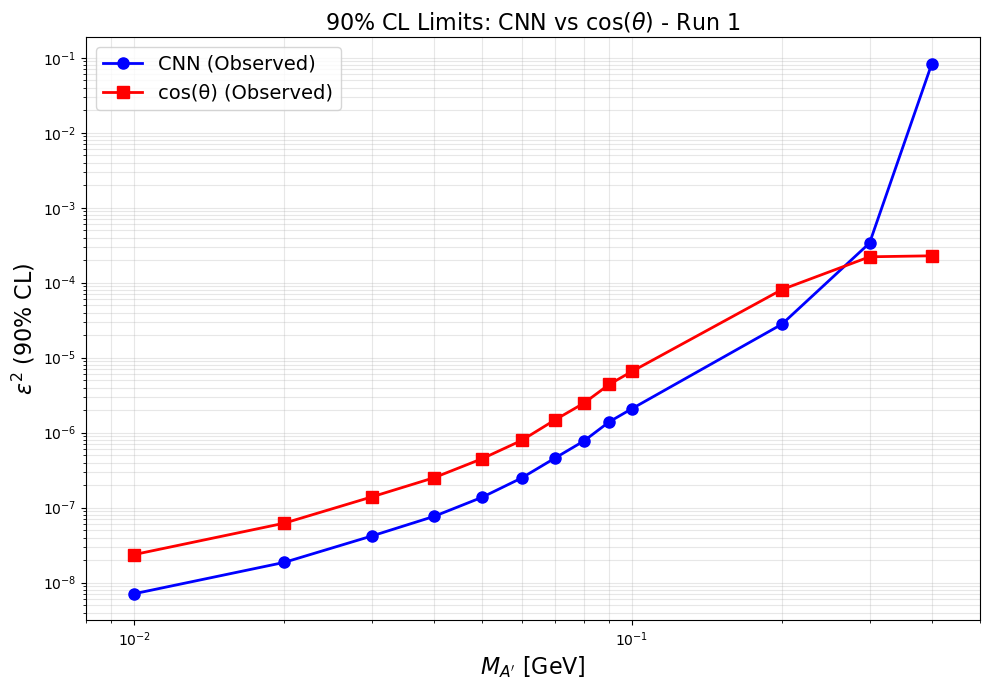


=== Sensitivity Ratio (cos(θ) / CNN) ===
    mass  epsilon_squared_obs_cnn  epsilon_squared_obs_costheta  \
0   0.01             7.120166e-09                  2.370930e-08   
1   0.02             1.861759e-08                  6.203074e-08   
2   0.03             4.189360e-08                  1.391854e-07   
3   0.04             7.644734e-08                  2.505759e-07   
4   0.05             1.377810e-07                  4.503214e-07   
5   0.06             2.487135e-07                  7.882361e-07   
6   0.07             4.582501e-07                  1.479078e-06   
7   0.08             7.732911e-07                  2.471144e-06   
8   0.09             1.396008e-06                  4.408203e-06   
9   0.10             2.094118e-06                  6.568165e-06   
10  0.20             2.795136e-05                  8.092951e-05   
11  0.30             3.376900e-04                  2.215028e-04   
12  0.40             8.290229e-02                  2.283629e-04   

    sensitivity_rat

In [9]:
# Load CNN results (already exists)
df_cnn = pd.read_csv(plot_dir / 'sensitivity_results_run1only.csv')

# Load cos(θ) results (you just created it)
df_costheta = pd.read_csv(plot_dir / 'costheta_sensitivity_results.csv')

# Plot comparison
fig, ax = plt.subplots(figsize=(10, 7))

ax.plot(df_cnn['mass'], df_cnn['epsilon_squared_obs'], 
        'b-o', lw=2, markersize=8, label='CNN (Observed)')
ax.plot(df_costheta['mass'], df_costheta['epsilon_squared_obs'],
        'r-s', lw=2, markersize=8, label='cos(θ) (Observed)')

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel(r'$M_{A^\prime}$ [GeV]', fontsize=16)
ax.set_ylabel(r'$\epsilon^2$ (90% CL)', fontsize=16)
ax.set_title(r'90% CL Limits: CNN vs cos($\theta$) - Run 1', fontsize=16)
ax.legend(fontsize=14, loc='best')
ax.grid(True, alpha=0.3, which='both')
ax.set_xlim(0.008, 0.5)

plt.tight_layout()
plt.savefig(plot_dir / 'cnn_vs_costheta_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

# Calculate sensitivity ratio
df_comparison = df_cnn.merge(df_costheta, on='mass', suffixes=('_cnn', '_costheta'))
df_comparison['sensitivity_ratio'] = df_comparison['epsilon_squared_obs_costheta'] / df_comparison['epsilon_squared_obs_cnn']

print("\n" + "="*60)
print("=== Sensitivity Ratio (cos(θ) / CNN) ===")
print("="*60)
print(df_comparison[['mass', 'epsilon_squared_obs_cnn', 'epsilon_squared_obs_costheta', 'sensitivity_ratio']])
print(f"\nMean ratio: {df_comparison['sensitivity_ratio'].mean():.2f}")